Design and train a RNN using Tensorflow and Keras


In [2]:
#step-1
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"amritpratya","key":"4580f955dfce926805f83384856b0a8d"}'}

In [3]:
#step-2
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [57]:
#step-3
!kaggle datasets download -d ak0212/indian-car-market-dataset
!unzip -q indian-car-market-dataset.zip -d /content/indian-car-market-dataset

Dataset URL: https://www.kaggle.com/datasets/ak0212/indian-car-market-dataset
License(s): MIT
  0% 0.00/140k [00:00<?, ?B/s]
100% 140k/140k [00:00<00:00, 339MB/s]


In [64]:
#step-4
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [65]:
#step-5
data_path = "/content/indian-car-market-dataset/car_dataset_india.csv"
data = pd.read_csv(data_path)

In [67]:
#step-6
features = data.drop(['Price', 'Car_ID'], axis=1)
target = data['Price'].values.reshape(-1, 1)

In [68]:
#step-7
numerical_cols = ['Year', 'Mileage', 'Engine_CC', 'Seating_Capacity', 'Service_Cost']
categorical_cols = ['Brand', 'Model', 'Fuel_Type', 'Transmission']

In [70]:
#step-8
scaler_X = StandardScaler()
scaler_y = StandardScaler()

target_scaled = scaler_y.fit_transform(target)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler_X, numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(features)

In [72]:
#step-9
X_tensor = torch.tensor(X_processed.toarray()).float()
y_tensor = torch.tensor(target_scaled).float()

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [73]:
#step-10
class RegressionModel(nn.Module):
    def __init__(self, input_size):
        super(RegressionModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x)

criterion = nn.MSELoss()

In [76]:
#step-11
optimizers = {
    'SGD' : lambda model: torch.optim.SGD(model.parameters(), lr=0.001),
    'Adam' : lambda model: torch.optim.Adam(model.parameters(), lr=0.001),
    'RMSprop' : lambda model: torch.optim.RMSprop(model.parameters(), lr=0.001)
}

def train_model(optimizer_fn, epochs=100):
    model = RegressionModel(X_train.shape[1])
    optimizer = optimizer_fn(model)
    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses[-1], losses

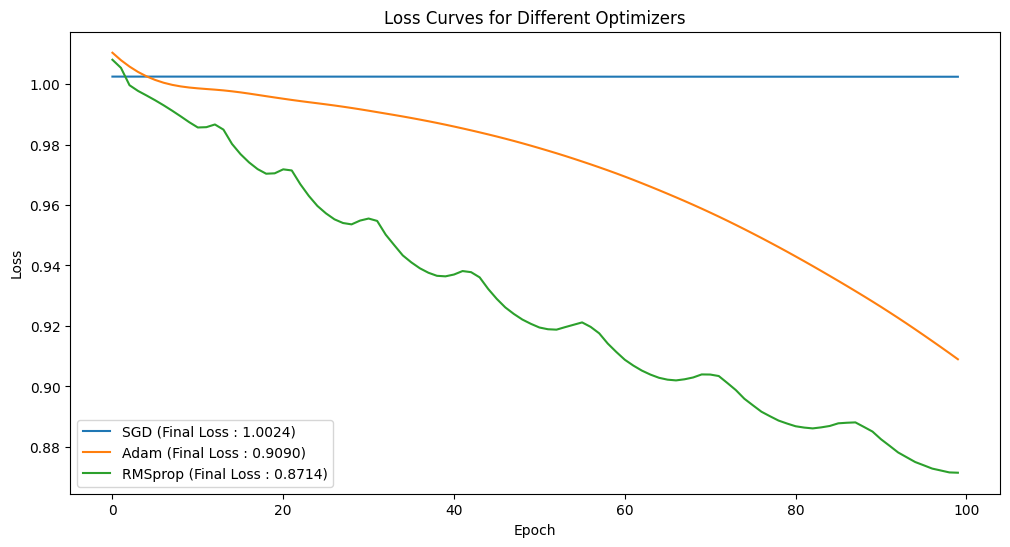

Final Loss Values for Each Optimizer:
SGD : 1.0024
Adam : 0.9090
RMSprop : 0.8714
Final Loss Values Curves for Each Optimizer (Scaled and Actual):
SGD : Scaled Loss: 1.002, Actual Loss (Approx): 2830891.62 (original price units)
Adam : Scaled Loss: 0.909, Actual Loss (Approx): 2788637.46 (original price units)
RMSprop : Scaled Loss: 0.8714, Actual Loss (Approx): 2771056.12 (original price units)


In [77]:
#step-12
final_losses = {}
loss_curves = {}

plt.figure(figsize=(12, 6))

for name, opt_fn in optimizers.items():
    final_loss, loss_history = train_model(opt_fn)
    final_losses[name] = final_loss
    loss_curves[name] = loss_history
    plt.plot(loss_history, label=f"{name} (Final Loss : {final_loss:.4f})")

plt.title('Loss Curves for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("Final Loss Values for Each Optimizer:")
for name, loss in final_losses.items():
    print(f"{name} : {loss:.4f}")

print("Final Loss Values Curves for Each Optimizer (Scaled and Actual):")
for name, loss in final_losses.items():
    actual_loss = scaler_y.inverse_transform([[np.sqrt(loss)]])[0][0]
    print(f"{name} : Scaled Loss: {loss:.4}, Actual Loss (Approx): {actual_loss:.2f} (original price units)")